# AIMMD toy tutorial: 1D double-well path sampling

This notebook is a **self-contained tutorial** that runs AIMMD on a cheap toy model:
a single particle evolving on a **1D double-well free-energy surface** (embedded in an
MDAnalysis trajectory).

You will learn how to:

- define a toy engine (`toy_mdrun`) and metastable states (`states_function`),
- build an initial path and a minimal committor network,
- configure `aimmd.Params` and launch an AIMMD run,
- inspect the produced path ensemble and compute simple projections/free-energy estimates,
- (optional) switch to RFPS and run a small multistate example.

The notebook is written to be readable first; performance is irrelevant for this toy model. However, to obtain the expected results for this model, you may need to increase the runtimes to produce more sampling and / or training data, as the defaults are for illustration but may be insufficient to adequately sample this system.

You will need a working AIMMD installation. Although we do not use this functionality here, gromacs is required in your path, since - as an integral component of AIMMD - its availability is checked at import time. (Hint: if you are using conda environments and have a modules-based gromacs install, consider adding an activation hook that sources a gromacs module, as a bash file under `path-to-env/etc/conda/activate.d/load_modules.sh`)

## 0. Imports and working directory

The toy data folders will be created relative to the notebook location:

- `../data/1d_double_well/` for the double-well example,
- `../data/1d_periodic/` for the optional multistate periodic example.

If you want a clean restart, remove thoes folders manually.


In [3]:
import os
from math import inf
from pathlib import PosixPath

import aimmd
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.special import expit

# Use the toy double-well folder shipped with the tutorial data.
DATA_DIR = PosixPath("../data/1d_double_well").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(DATA_DIR)

print("Working directory:", os.getcwd())


Working directory: /home/covino-shared/data/lichtinger/LigandAIMMD/new_aimmd/AIMMD/examples/data/data/data/1d_double_well


## 1. Toy dynamics and state definition

### 1.1 Dynamics: overdamped Langevin on a double well

We evolve a single coordinate `x` with overdamped Langevin dynamics:

- a deterministic drift given by a double-well force field,
- plus Gaussian noise with diffusion coefficient `D`.

We integrate for a small internal number of steps each time AIMMD requests a new MD frame.
That gives a trajectory that qualitatively behaves like a coarse-grained MD simulation.


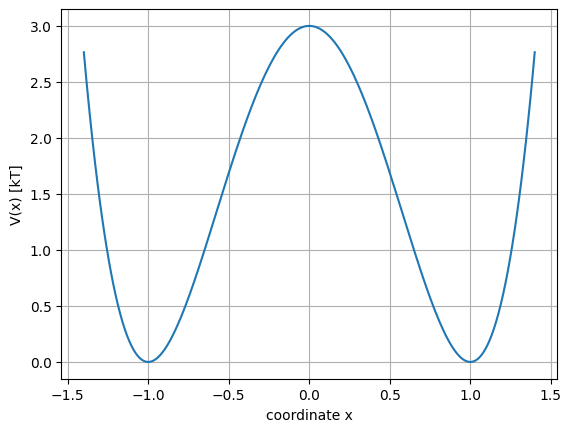

In [4]:
def toy_mdrun(ts, G: float = 3.0, dt: float = 1e-4, D: float = 1.0):
    """Propagate one MDAnalysis `Timestep` using overdamped Langevin dynamics.

    Parameters
    ----------
    ts
        MDAnalysis timestep. We read/write positions in-place.
    G
        Barrier height parameter for the double-well potential.
    dt
        Internal integration time step.
    D
        Diffusion coefficient controlling the noise amplitude.

    Notes
    -----
    - We treat positions as a scalar `x` stored in `ts.positions[0, 0]`.
    - The update is repeated `n_inner=100` times per emitted trajectory frame.
    """
    sqrt2Dt = np.sqrt(2 * D * dt)
    x = ts.positions

    # Inner integrator steps per emitted trajectory frame.
    for _ in range(100):
        # Force from V(x) = G (x^2 - 1)^2  ->  dV/dx = 4G x (x^2 - 1)
        f = G * 4 * x * (x**2 - 1)
        x = x - f * dt + sqrt2Dt * np.random.normal()

    ts.positions = x


# Visualize the potential energy surface (in kT units).
G = toy_mdrun.__defaults__[0]
pes = lambda x: G * (x**2 - 1) ** 2

xgrid = np.linspace(-1.4, 1.4, 200)
plt.plot(xgrid, pes(xgrid))
plt.xlabel("coordinate x")
plt.ylabel("V(x) [kT]")
plt.grid(True)
plt.show()


### 1.2 Metastable states

We define two end states and a reactive region:

- **A**: `x < -0.7`
- **B**: `x > 0.7`
- **R**: the intermediate region, where shooting starts and where transitions happen

AIMMD expects a function that maps a trajectory (iterable of timesteps) to a **per-frame**
array of labels.


In [5]:
def states_function(trajectory):
    """Assign a discrete state label to each trajectory frame."""
    labels = []
    for ts in trajectory:
        x = ts.positions[0][0]
        if x < -0.7:
            labels.append("A")
        elif x > 0.7:
            labels.append("B")
        else:
            labels.append("R")
    return np.array(labels, dtype="<U1")


## 2. Build an initial path

AIMMD needs at least one **initial trajectory** (or "path") that connects regions of phase space.
For this toy model we simply *sweep* the coordinate from left to right and write it as an XTC.

This is not a physical trajectory; it is just a convenient starting point for training and for
seeding the first shooting points.


In [6]:
# Build a 1-atom MDAnalysis Universe with an in-memory trajectory.
universe = mda.Universe.empty(1, trajectory=True)
atoms = universe.atoms
ts = universe.trajectory.ts

# Write a simple sweep trajectory to disk.
initial_xtc = PosixPath("initial.xtc")
with mda.coordinates.XTC.XTCWriter(str(initial_xtc), n_atoms=1) as writer:
    for x in np.arange(-1.4, 1.4, 0.01):
        ts.positions = x
        writer.write(atoms)

print("Wrote:", initial_xtc.resolve())


Wrote: /home/covino-shared/data/lichtinger/LigandAIMMD/new_aimmd/AIMMD/examples/data/data/data/1d_double_well/initial.xtc


## 3. Define a minimal committor model

In AIMMD the committor (or a monotonic surrogate) is typically approximated by a small network.

Here we create a tiny MLP in a separate `network.py` module **and instantiate it there**.
This mirrors the recommended project layout: the notebook imports a ready-to-use model object.

Why write a module instead of defining the class inline?

- `aimmd.Params` is meant to be serializable/reproducible: having the model defined in a file
  makes it easier to reload exactly the same architecture later.


In [7]:
# Write a standalone module that defines the model *and* constructs an instance.
# The notebook will import `network` (the instance), not `Network` (the class).

network_py = PosixPath("network.py")
network_py.write_text(
    '''"""
Network used by AIMMD.

This module is written by the notebook so the model can be imported from a
standalone file (similar to how it would be done in a normal project).
"""

import torch
import torch.nn as nn


class Network(nn.Module):
    """Small MLP mapping a 1D input to a 1D output."""

    def __init__(self, n: int = 64):
        super().__init__()

        # Optional metadata container (unused by forward, but harmless to keep).
        self.call_kwargs = {}

        self.input = nn.Linear(1, n)
        self.layer = nn.Linear(n, n)
        self.activation = nn.ReLU()
        self.output = nn.Linear(n, 1)

        self.reset_parameters()

    def forward(self, x):
        # AIMMD may pass coordinates with shape (n_frames, 3). We only use the first component.
        x = self.activation(self.input(x[:, :1]))
        x = self.activation(self.layer(x))
        x = self.output(x)
        return x

    def reset_parameters(self):
        self.input.reset_parameters()
        self.layer.reset_parameters()
        self.output.reset_parameters()


# Ready-to-use model instance (import this from the notebook).
network = Network()
''',
    encoding="utf-8",
)

print("Wrote:", network_py.resolve())

# Import the instance created in the module.
from network import network

network


Wrote: /home/covino-shared/data/lichtinger/LigandAIMMD/new_aimmd/AIMMD/examples/data/data/data/1d_double_well/network.py


Network(
  (input): Linear(in_features=1, out_features=64, bias=True)
  (layer): Linear(in_features=64, out_features=64, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=64, out_features=1, bias=True)
)

## 4. Create `aimmd.Params`

`Params` is the *single source of truth* for a run: it stores

- the state definition,
- how to launch dynamics (engine + engine kwargs),
- the committor model,
- I/O conventions (working folders, filenames),
- and the sampling/training hyperparameters.

In a typical project you would create a `params.py` file. For a tutorial it is convenient
to build `Params` inline; AIMMD still writes a reproducible parameters file when a run
is initialized.


In [8]:
params = aimmd.Params(
    # states and dynamics
    states_function=states_function,
    engine="toy",
    toy_mdrun=toy_mdrun,

    # committor model
    network=network,

    # initial data
    initial_paths="initial.xtc",

    # sampling setup
    chain_type="tps",
)

params


Written full params with descriptions to 'params.py'


Params params.py

### 4.1 Inspect the initial path object

`params.initial_paths` returns AIMMD `Path` objects. Each `Path` stores a list of trajectory
segments plus cached derived data (states, descriptors, values) when computed.


In [14]:
print("Initial paths:", params.initial_paths)

path0 = params.initial_paths[0]
print("First initial path:", path0)
print("  states:", np.unique(path0.states))
print("  type:", path0.type)
print("  n_frames:", len(path0))


Initial paths: PathEnsemble with 1 paths
First initial path: Path with 143 frames
  states: ['A' 'B' 'R']
  type: ARBA
  n_frames: 143


## 5. Sanity-check the engine

Before launching AIMMD, it is useful to check that:

- the engine can write a short trajectory,
- the state function behaves as expected,
- the committor model can be evaluated on coordinates.

This also illustrates how AIMMD uses a "simulation id" to name temporary outputs.


In [12]:
# Pick a starting frame from the middle of the sweep trajectory.
initial_path = params.initial_paths[0]
starting_frame = initial_path[len(initial_path) // 2]

# Run a short test simulation and write `test.xtc`.
params.initialize_simulation(starting_frame, "test")
params.run_simulation("test", walltime=1.0)


Appending to 'test.xtc'
[PID 2841654, TID 140357064955456: toy engine run] starting (Fri Mar  6 15:10:44 2026)
[PID 2841654, TID 140356981093952: toy engine check] starting (Fri Mar  6 15:10:44 2026)
[PID 2841654, TID 140357064955456: toy engine run] exited correctly
[PID 2841654, TID 140356981093952: toy engine check] exited correctly


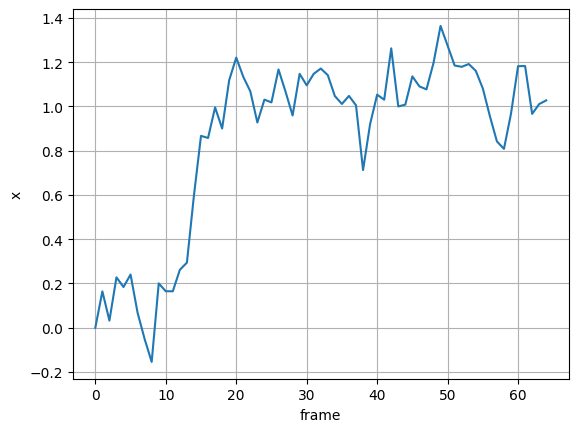

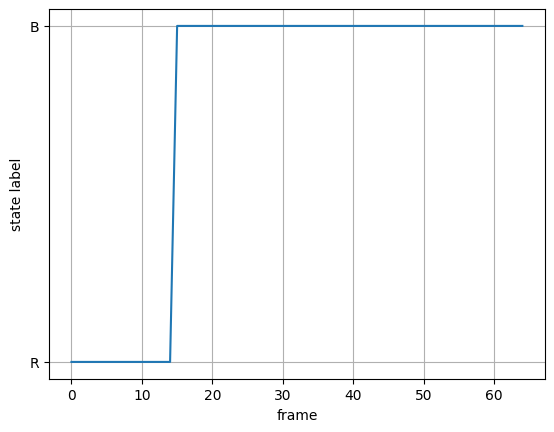

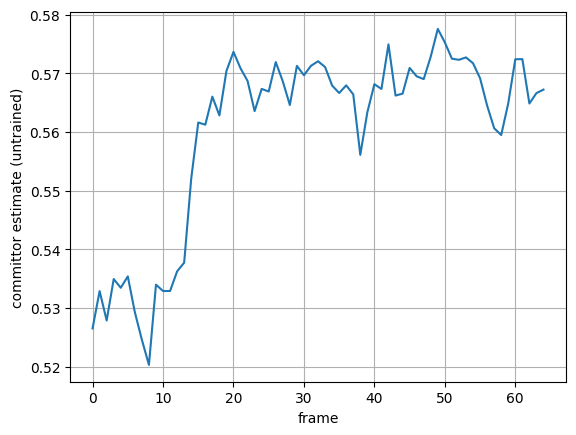

In [15]:
test_path = aimmd.Path("test.xtc")

plt.plot(test_path.positions[:, 0, 0])
plt.xlabel("frame")
plt.ylabel("x")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(params.states_function(test_path))
plt.xlabel("frame")
plt.ylabel("state label")
plt.grid(True)
plt.show()

# Evaluate the (untrained) network output -> expit() maps logits to (0, 1).
plt.figure()
plt.plot(expit(params.values_function(test_path.positions)))
plt.xlabel("frame")
plt.ylabel("committor estimate (untrained)")
plt.grid(True)
plt.show()


## 6. Launch an AIMMD run (`run1`)

`aimmd.Launcher` orchestrates:

- training rounds,
- one or more shooting chains (TPS or RFPS),
- optional free simulations,
- job-script creation for clusters.

The run is placed in a folder (`run1/` here).


In [16]:
launcher = aimmd.Launcher(params, "run1")
launcher


Launcher of 1 run ('run1')

### 6.1 One training round only

Calling `launcher.run(0)` performs a single training round *without* launching shooting chains
and *without* free simulations. This is the smallest useful run: it produces a trained model
from whatever training data is available (initial path endpoints here).


In [17]:
launcher.run(0)


Assigned parameters file 'params.py'
+++ created 'run1'
+++ created 'run1/initialARB'
+++ saved 'run1/initialARB/initial.xtc.trr' (from: 'initial.xtc')
+++ saved 'run1/initialARB/initial.xtc.trr.states.npy'
[PID 2841654, TID 140364353083200: "run1" ARB trainer] starting (Fri Mar  6 15:11:18 2026)
...   args: ('params.py', 'run1', np.int64(0), np.int64(28), 1, 'stdout', inf, np.float64(inf), np.float64(inf), 59.0, 'train', np.float64(1.0), False)
Press Control+C to interrupt.

Worker's resources info
-----------------------
LocalID 0
CPU ids: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
GPU ids: 0
-----------------------
run1: 0 trajs [00:00, ? trajs/s]
Loading pre-existing network parameters (Fri Mar  6 15:11:18 2026)

Loading current path ensemble (Fri Mar  6 15:11:18 2026)
... 0 new frames

Training the network (round 1, (Fri Mar  6 15:11:18 2026))

Collected         1 in A frames (     1 paths),
                  1 in B frames (     1 paths),
           

### 6.2 Load the trained network and evaluate committor predictions

The trained network weights are written into the run folder. Here we reload them into the
in-memory model instance and re-evaluate the committor along the test trajectory.


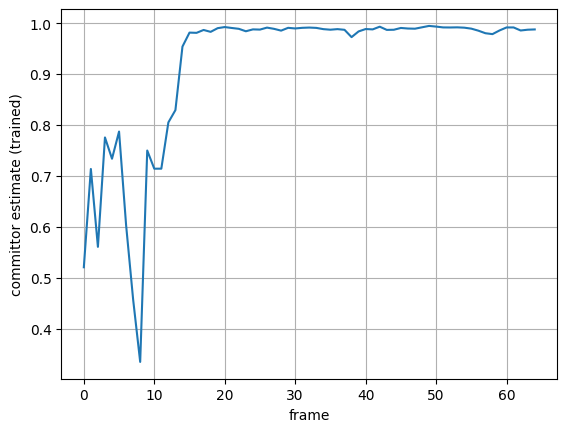

In [18]:
plt.figure()

# Load the weights produced by the training round.
network.load_state_dict(torch.load("run1/networkARB.h5"))

# Re-evaluate on the test trajectory.
plt.plot(expit(params.values_function(test_path.positions)))
plt.xlabel("frame")
plt.ylabel("committor estimate (trained)")
plt.grid(True)
plt.show()


## 7. Run TPS shooting

A TPS chain repeatedly:
1. selects a shooting point from the previously accepted path in the chain,
2. launches short unbiased simulations forward/backward,
3. accepts or rejects the resulting path according to the ensemble definition.

In this tutorial we keep everything small (few steps, short walltime).
On a terminal you will typically see a live progress bar; in notebooks output may appear
line-by-line depending on the stdout backend.


In [19]:
# One TPS chain, limited number of shooting steps.
launcher.run(n=1, nsteps=30, walltime=120)


Assigned parameters file 'params.py'
--- removed run1/initialARB/initial.xtc.trr.states.npy
--- removed run1/initialARB/initial.xtc.trr
+++ saved 'run1/initialARB/initial.xtc.trr' (from: 'initial.xtc')
+++ saved 'run1/initialARB/initial.xtc.trr.states.npy'
+++ created run1/chainR0
[PID 2847995, TID 140546883319616: "run1" ARB trainer] starting (Fri Mar  6 15:13:47 2026)
...   args: ('params.py', 'run1', np.int64(1), np.int64(14), 1, 'trainARB.log', 120.0, np.float64(30.0), np.float64(inf), 59.0, 'train', np.float64(inf), True)
[PID 2847994, TID 140597403236160: "run1" chainR0] starting (Fri Mar  6 15:13:47 2026)
...   args: ('params.py', 'run1', np.int64(0), np.int64(14), 1, 'chainR0/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 0, False)
[PID 2847995, TID 140546883319616: "run1" ARB trainer] exited correctly
[PID 2847994, TID 140597403236160: "run1" chainR0] exited correctly


### 7.1 Append and expand to multiple chains in parallel

`n=3` launches three independent shooting chains (separate workers), appending to the already simulated one (`run1/shootR0`). Here we stop the run after
a cumulative number of produced frames across chains (`nframes=10000`).


In [22]:
launcher.run(n=3, nsteps=50, walltime=60)


Assigned parameters file 'params.py'
--- removed run1/initialARB/initial.xtc.trr.states.npy
--- removed run1/initialARB/initial.xtc.trr.values.npy
--- removed run1/initialARB/initial.xtc.trr
+++ saved 'run1/initialARB/initial.xtc.trr' (from: 'initial.xtc')
+++ saved 'run1/initialARB/initial.xtc.trr.states.npy'
[PID 2856590, TID 139817411200832: "run1" chainR2] starting (Fri Mar  6 15:23:11 2026)
...   args: ('params.py', 'run1', np.int64(2), np.int64(7), 1, 'chainR2/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 2, False)
[PID 2856588, TID 140093756548928: "run1" chainR0] starting (Fri Mar  6 15:23:11 2026)
...   args: ('params.py', 'run1', np.int64(0), np.int64(7), 1, 'chainR0/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 0, False)
[PID 2856591, TID 139928508892992: "run1" ARB trainer] starting (Fri Mar  6 15:23:11 2026)
...   args: ('params.py', 'run1', np.int64(3), np.int64(7), 1, 'trainARB.log', 60.0, np.float64(50.0), np.float64(inf), 59.0, 'train', np.float64(inf), True)
[PID 

### 7.2 Simulate without retraining (optional)

If you want to *keep the model fixed* but still simulated and refresh selection densities/bins, you can run
with `nrounds=-1`. This is mainly useful for analysis workflows.


In [23]:
launcher.run(n=3, walltime=60, nrounds=-1)


Assigned parameters file 'params.py'
--- removed run1/initialARB/initial.xtc.trr.states.npy
--- removed run1/initialARB/initial.xtc.trr.values.npy
--- removed run1/initialARB/initial.xtc.trr
+++ saved 'run1/initialARB/initial.xtc.trr' (from: 'initial.xtc')
+++ saved 'run1/initialARB/initial.xtc.trr.states.npy'
[PID 2858258, TID 140688390190912: "run1" ARB trainer] starting (Fri Mar  6 15:24:55 2026)
...   args: ('params.py', 'run1', np.int64(3), np.int64(7), 1, 'trainARB.log', 60.0, np.float64(inf), np.float64(inf), 59.0, 'train', np.float64(-1.0), True)
[PID 2858257, TID 140441812629312: "run1" chainR2] starting (Fri Mar  6 15:24:55 2026)
...   args: ('params.py', 'run1', np.int64(2), np.int64(7), 1, 'chainR2/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 2, False)
[PID 2858256, TID 140416463652672: "run1" chainR1] starting (Fri Mar  6 15:24:55 2026)
...   args: ('params.py', 'run1', np.int64(1), np.int64(7), 1, 'chainR1/worker.log', inf, inf, inf, 59.0, 'shoot', 'R', 1, False)
[PID 

## 8. Cluster execution (SLURM job script template)

For real systems you will typically run AIMMD on a cluster.
`Launcher.create_job()` writes a job script that starts the required worker processes.

Here we generate a small script for inspection.


In [24]:
launcher.create_job("job.sh", 2, 1, 1)
print(PosixPath("job.sh").read_text())


Assigned parameters file 'params.py'
--- removed run1/initialARB/initial.xtc.trr.states.npy
--- removed run1/initialARB/initial.xtc.trr
+++ saved 'run1/initialARB/initial.xtc.trr' (from: 'initial.xtc')
+++ saved 'run1/initialARB/initial.xtc.trr.states.npy'
+++ created run1/freeA
+++ created run1/freeB
#!/bin/bash -x
#SBATCH --job-name=AIMMD
#SBATCH --mail-type=FAIL
#SBATCH --ntasks-per-node=1
#SBATCH --cpus-per-task=1
#SBATCH --nodes=5
#SBATCH --time=24:00:00

# default names
PYTHON="/home/lichtinger/anaconda3/envs/new_aimmd/bin/python"
WORKER="/home/covino-shared/data/lichtinger/LigandAIMMD/new_aimmd/AIMMD/aimmd/worker/run.py"

# enable job control
set -m

# workers
# "run1" freeA (worker0)
srun --exclusive --nodes=1 --ntasks=1 --cpus-per-task=1 --gpus-per-task=0 \
  "${PYTHON}" "${WORKER}" "params.py" "run1" "0" "skip" "skip" "freeA/worker0.log" "inf" "inf" "inf" "59.0" "free" "A" "0" "1" "True" &

# "run1" freeB (worker0)
srun --exclusive --nodes=1 --ntasks=1 --cpus-per-task=1 --gpu

## 9. Inspect and analyze the generated paths

AIMMD stores all sampled paths on disk. The analysis entry point is the `PathEnsemble`
associated with a run folder.


In [25]:
pathensemble = params.pathensemble("run1")
pathensemble


PathEnsemble with 38 paths

### 9.1 Transition path ensemble (TPE)

`are_transitions()` selects paths that start in one end state and end in the other.
The resulting subset carries the **statistical weights** produced by TPS.


In [27]:
tpe = pathensemble[pathensemble.are_transitions()]
tpe, tpe.fnames, tpe.weights


(PathEnsemble with 17 paths,
 array(['run1/chainR0/path000002.xtc', 'run1/chainR0/path000005.xtc',
        'run1/chainR0/path000009.xtc', 'run1/chainR0/path000010.xtc',
        'run1/chainR0/path000011.xtc', 'run1/chainR0/path000015.xtc',
        'run1/chainR0/path000018.xtc', 'run1/chainR0/path000020.xtc',
        'run1/chainR1/path000004.xtc', 'run1/chainR1/path000007.xtc',
        'run1/chainR1/path000008.xtc', 'run1/chainR2/path000001.xtc',
        'run1/chainR2/path000002.xtc', 'run1/chainR2/path000003.xtc',
        'run1/chainR2/path000007.xtc', 'run1/chainR2/path000008.xtc',
        'run1/chainR2/path000009.xtc'], dtype='<U27'),
 array([3., 4., 1., 8., 0., 0., 2., 1., 3., 3., 0., 1., 1., 4., 1., 1., 1.]))

### 9.2 Visualize trajectories and committor traces

For the toy model the coordinate is just `x(t) = positions[:, 0, 0]`.
We also plot the learned committor estimate along each path.


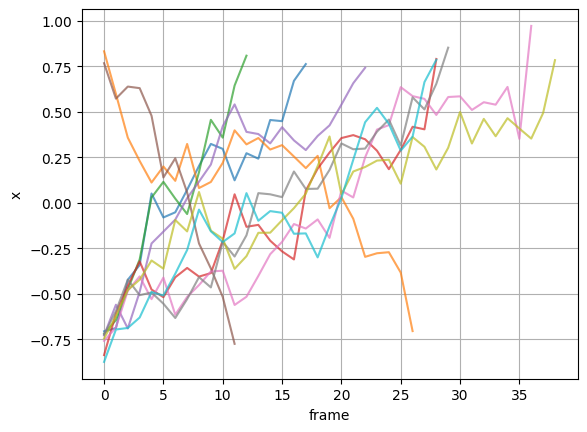

In [28]:
# Plot a handful of recent transition paths in coordinate space.
for path in tpe[-10:]:
    plt.plot(path.coordinates[:, 0], alpha=0.7)

plt.xlabel("frame")
plt.ylabel("x")
plt.grid(True)
plt.show()


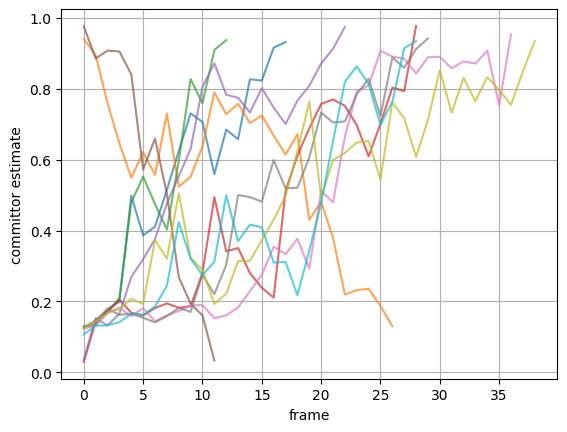

In [29]:
# Plot committor estimates along the same paths.
for path in tpe[-10:]:
    path.compute(*params.compute_values_args)
    plt.plot(expit(path.values), alpha=0.7)

plt.xlabel("frame")
plt.ylabel("committor estimate")
plt.grid(True)
plt.show()


### 9.3 Forcing a recomputation of committor values (optional)

Normally the training process updates committor values consistently as the model changes.
If you manually modify network weights and want to overwrite stored `path.values`, use
`overwrite=True`.


In [30]:
params.update_network("run1")
pathensemble.compute(*params.compute_values_args, overwrite=True)

# You can also compute on subsets or single paths.
tpe.compute(*params.compute_values_args, overwrite=True)
_ = tpe[-1].compute(*params.compute_values_args, overwrite=True, return_result=True)


### 9.4 Other path types

Besides transition paths, the ensemble contains excursions such as `ARA` (leave A, enter R,
return to A). `extract()` selects by `path.type` label.


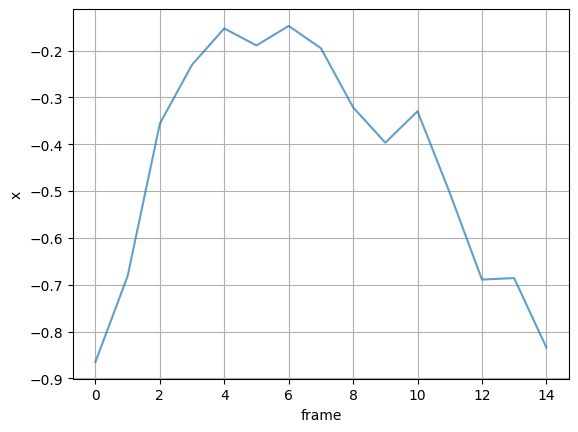

In [31]:
for path in pathensemble.extract("ARA")[::10]:
    plt.plot(path.coordinates[:, 0], alpha=0.7)

plt.xlabel("frame")
plt.ylabel("x")
plt.grid(True)
plt.show()


### 9.5 Simple projections: density and free energy along a coordinate

`PathEnsemble.project()` bins data extracted from each path and returns a normalized density
estimate (up to the conventions of the underlying method).

Here we:
- project the TPE onto the coordinate `x`,
- and separately onto the committor values.

For a free-energy-like curve we plot `F(x) = -log ρ(x)` (up to an additive constant).


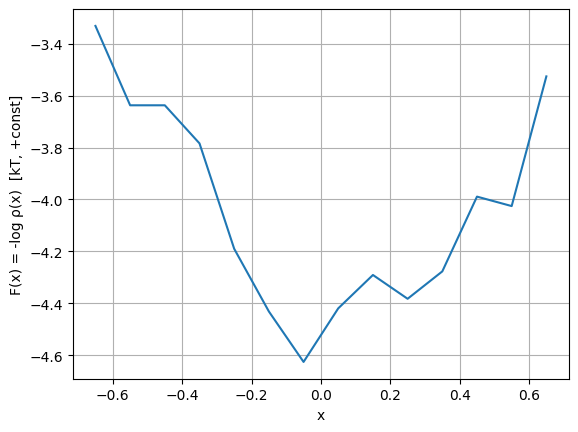

In [33]:
# Coordinate-space projection.
bins_x = np.arange(-1.4, 1.4, 0.1)
rho_x = tpe.project(bins=bins_x, function=lambda x: x[:, 0], source="coordinates")

x_centers = 0.5 * (bins_x[:-1] + bins_x[1:])
F_x = np.full_like(x_centers, np.nan, dtype=float)
mask = rho_x > 0
F_x[mask] = -np.log(rho_x[mask])

plt.plot(x_centers, F_x)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("F(x) = -log ρ(x)  [kT, +const]")
plt.show()


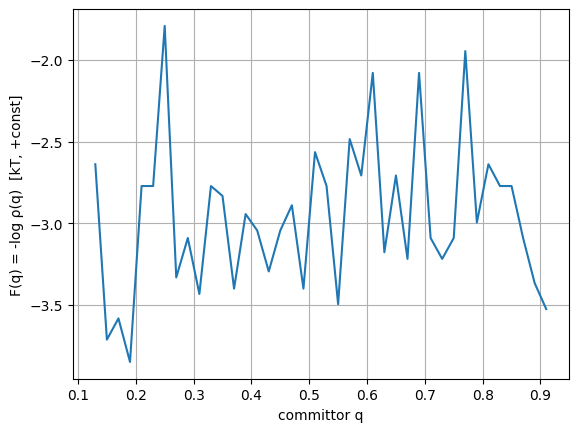

In [34]:
# Committor-space projection.
# For this toy, committor values are stored as logits; apply expit() to map to (0, 1).
bins_q = np.linspace(0.0, 1.0, 51)

# Ensure values exist.
tpe.compute(*params.compute_values_args)

rho_q = tpe.project(bins=bins_q, function=lambda v: expit(v), source="values")
q_centers = 0.5 * (bins_q[:-1] + bins_q[1:])

F_q = np.full_like(q_centers, np.nan, dtype=float)
mask = rho_q > 0
F_q[mask] = -np.log(rho_q[mask])

plt.plot(q_centers, F_q)
plt.grid(True)
plt.xlabel("committor q")
plt.ylabel("F(q) = -log ρ(q)  [kT, +const]")
plt.show()


## 10. RFPS + free simulations (rate-oriented workflow)

RFPS (rejection-free path sampling) augments TPS by enhancing exploration **within the reactive
region**, which can be helpful when you care about *rates* and need better coverage.

In this section we:

1. switch to RFPS and run a small production,
2. inspect the rate estimates reported in the training log,
3. reweight the produced path ensemble and project it.


In [35]:
# Switch to RFPS and increase the number of bins used internally for selection/reweighting.
params.chain_type = "rfps"
params.nbins = 10

launcher = aimmd.Launcher(params, "run2")

# Run with multiple workers (arguments depend on your AIMMD version/configuration).
# More chains in parallel can reduce the risk of repeatedly picking boundary-adjacent points,
# when `params.density_adjustment` is `True`
launcher.run(2, 2, 2, nsteps=50, walltime=120)


run1: 0 trajs [16:14, ? trajs/s]
run1: 0 frames [16:14, ? frames/s]
Written full params with descriptions to 'params1.py'
+++ created 'run2'
+++ created 'run2/initialARB'
+++ saved 'run2/initialARB/initial.xtc.trr' (from: 'initial.xtc')
+++ saved 'run2/initialARB/initial.xtc.trr.states.npy'
+++ created run2/freeA
+++ created run2/freeB
+++ created run2/chainR0
+++ created run2/chainR1
[PID 2860898, TID 140054408648512: "run2" freeA (worker1)] starting (Fri Mar  6 15:27:42 2026)
...   args: ('params1.py', 'run2', np.int64(1), np.int64(4), 1, 'freeA/worker1.log', inf, inf, inf, 59.0, 'free', 'A', 1, np.int64(2), np.True_)
[PID 2860904, TID 140001152579392: "run2" ARB trainer] starting (Fri Mar  6 15:27:42 2026)
...   args: ('params1.py', 'run2', np.int64(6), np.int64(4), 1, 'trainARB.log', 120.0, np.float64(50.0), np.float64(inf), 59.0, 'train', np.float64(inf), True)
[PID 2860897, TID 140179936343872: "run2" freeA (worker0)] starting (Fri Mar  6 15:27:42 2026)
[PID 2860903, TID 14012605

### 10.1 Load the RFPS ensemble and count transitions


In [36]:
pathensemble = params.pathensemble("run2")
print(pathensemble, pathensemble.are_transitions().sum(), "transitions")


PathEnsemble with 2015 paths 25 transitions


### 10.2 Rate estimates from the training log

The trainer periodically reports cumulative-time rate estimates.
These become meaningful only after you have accumulated **enough independent transitions**
(think: order 10–100 for stable estimates in real systems).


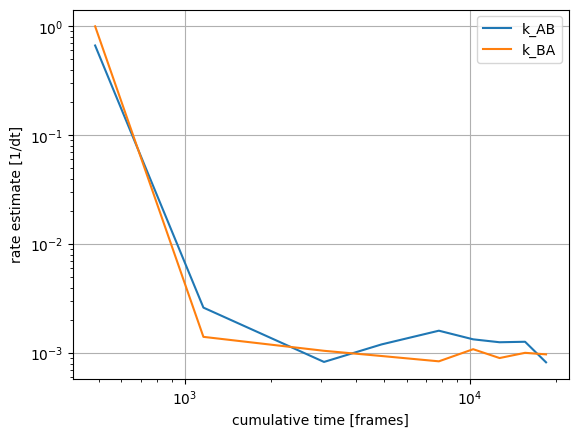

In [37]:
from aimmd.analysis.utils import extract_rate_estimates_from_log_file

t, k12, k21 = extract_rate_estimates_from_log_file("run2/trainARB.log")

plt.plot(t, k12, label="k_AB")
plt.plot(t, k21, label="k_BA")
plt.gca().set_yscale("log")
plt.gca().set_xscale("log")
plt.grid(True)
plt.xlabel("cumulative time [frames]")
plt.ylabel("rate estimate [1/dt]")
plt.legend()
plt.show()


### 10.3 Reweight and compute crossing-probability diagnostics

For RFPS workflows it is often helpful to:
- recompute committor values for all frames (including state interiors),
- run reweighting for both directions,
- inspect crossing probabilities vs committor.

The `PathEnsemble.reweight()` helper returns several intermediate arrays used for diagnostics.


In [38]:
params.update_network("run2")

# Ensure committor values exist for all frames.
n_new_values = pathensemble.compute(*params.compute_values_args)
print("computed", n_new_values, "new values")

rw_p = params.reweight_parameters.copy()

# Reweight both directions.
result_AB = pathensemble.reweight(params.states, **rw_p)
result_BA = pathensemble.reweight(params.states[::-1], **rw_p)

w1, i1, factors1, shooting_values1, extremes1, xP1, f1, m1 = result_AB
w2, i2, factors2, shooting_values2, extremes2, xP2, f2, m2 = result_BA


computed 2608 new values


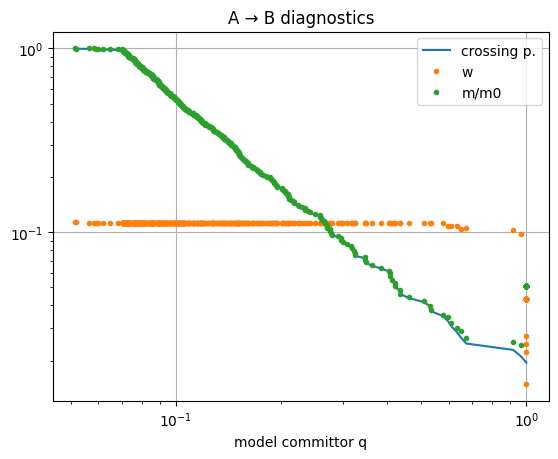

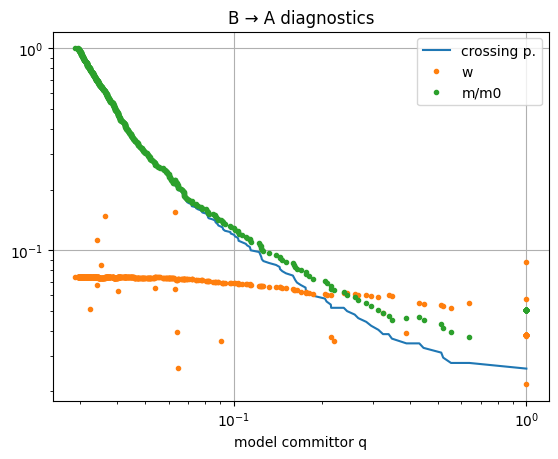

In [40]:
# Crossing probability diagnostics.
plt.plot(expit(extremes1), xP1, label="crossing p.")
plt.plot(expit(extremes1), w1[i1], ".", label="w")
plt.plot(expit(extremes1), m1 / m1[0], ".", label="m/m0")
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.grid(True)
plt.title("A → B diagnostics")
plt.xlabel("model committor q")
plt.legend()
plt.show()

plt.figure()
plt.plot(expit(extremes2), xP2, label="crossing p.")
plt.plot(expit(extremes2), w2[i2], ".", label="w")
plt.plot(expit(extremes2), m2 / m2[0], ".", label="m/m0")
plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
plt.grid(True)
plt.title("B → A diagnostics")
plt.xlabel("model committor q")
plt.legend()
plt.show()


In [41]:
# Simple rate-from-mean-length diagnostic (toy-level; do not over-interpret).
lengths = pathensemble.n_frames.astype(float)

k12_est = np.sum(w1 * lengths)
k12_est = 1.0 / k12_est if k12_est else np.nan

k21_est = np.sum(w2 * lengths)
k21_est = 1.0 / k21_est if k21_est else np.nan

print(f"k_AB estimate: {k12_est:.3e} [1/dt]")
print(f"k_BA estimate: {k21_est:.3e} [1/dt]")
print(f"total frames: {pathensemble.n_frames.sum()}")


k_AB estimate: 8.930e-04 [1/dt]
k_BA estimate: 1.283e-03 [1/dt]
total frames: 23584


### 10.4 Project the (reweighted) ensemble

For a quick qualitative check we combine weights from both directions and compare:

- the true potential energy surface `V(x)` (known analytically),
- a free-energy-like curve from the projected reweighted ensemble.


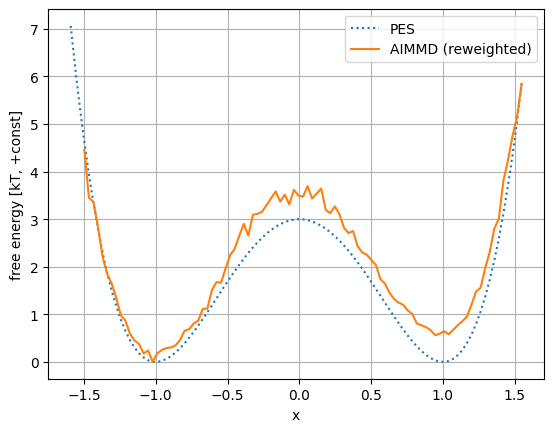

In [42]:
# Combine weights for a simple "overall" projection.
pathensemble.weights = w1 + w2

coords = np.concatenate(pathensemble.coordinates)[:, 0]
bins = np.linspace(coords.min(), coords.max(), 101)
rho = pathensemble.project(bins=bins, function=lambda x: x[:, 0], source="coordinates")

x_centers = 0.5 * (bins[:-1] + bins[1:])
F = np.full_like(x_centers, np.nan, dtype=float)
mask = rho > 0
F[mask] = -np.log(rho[mask])
F = F - np.nanmin(F)

plt.plot(x_centers, pes(x_centers), ":", label="PES")
plt.plot(x_centers, F, label="AIMMD (reweighted)")
plt.grid(True)
plt.legend()
plt.xlabel("x")
plt.ylabel("free energy [kT, +const]")
plt.show()


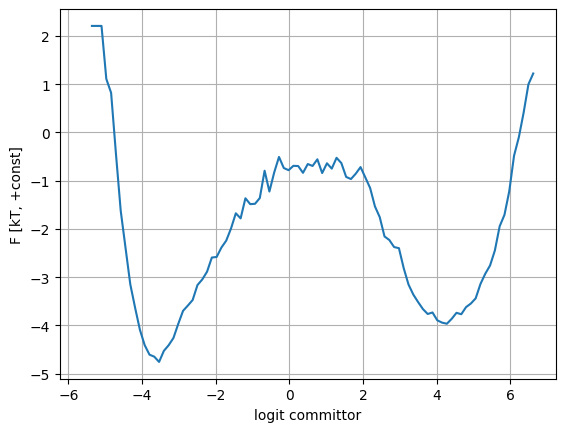

In [43]:
# Free energy in logit-committor space.
values = np.concatenate(pathensemble.values)
bins = np.linspace(values.min(), values.max(), 101)
rho = pathensemble.project(bins=bins)  # default source='values'
x_centers = 0.5 * (bins[:-1] + bins[1:])

F = np.full_like(x_centers, np.nan, dtype=float)
mask = rho > 0
F[mask] = -np.log(rho[mask])

plt.plot(x_centers, F)
plt.grid(True)
plt.xlabel("logit committor")
plt.ylabel("F [kT, +const]")
plt.show()


## 11. Committor validation by brute-force shooting (optional)

A pragmatic way to validate a learned committor is to:

1. sample configurations across committor bins,
2. launch many short unbiased shootings from each configuration,
3. estimate the *empirical* committor as the fraction of shootings that reach B before A,
4. compare empirical committor vs model prediction.

This is expensive for real systems, but cheap for the toy model.


In [44]:
# Sample configurations approximately uniformly across logit-committor bins.
bins = np.linspace(-4, 4, 11)
print("committor bin boundaries:", expit(bins))

validation_set = aimmd.Path()
excursions = pathensemble[pathensemble.are_excursions()]

for vmin, vmax in zip(bins[:-1], bins[1:]):
    validation_set += excursions.sample(1, vmin=vmin, vmax=vmax)

validation_set.write("committor_validation.xtc", overwrite=True)
validation_set.values


committor bin boundaries: [0.018 0.039 0.083 0.168 0.31  0.5   0.69  0.832 0.917 0.961 0.982]


array([-2.542, -2.336, -1.198, -0.62 ,  0.069,  1.051,  2.379,  2.983,
        3.353], dtype=float32)

In [45]:
# Reuse the validation set as the initial path list.
params.initial_paths = "committor_validation.xtc"

# Run brute-force shooting in "sweep" mode (no training).
launcher = aimmd.Launcher(params, "validation")

nframes = len(aimmd.Path("committor_validation.xtc"))
launcher.run(5, reactive_region_mode="sweep", nsteps=10 * nframes)


Perhaps you are using it for brute-force shooting?
Written full params with descriptions to 'params2.py'
+++ created 'validation'
+++ created 'validation/initialARB'
+++ saved 'validation/initialARB/committor_validation.xtc.trr' (from: 'committor_validation.xtc')
+++ saved 'validation/initialARB/committor_validation.xtc.trr.states.npy'
+++ created validation/sweepR0
+++ created validation/sweepR1
+++ created validation/sweepR2
+++ created validation/sweepR3
+++ created validation/sweepR4


[PID 2864260, TID 140451579459392: "validation" sweepR2] starting (Fri Mar  6 15:31:02 2026)[PID 2864261, TID 140421569521472: "validation" sweepR3] starting (Fri Mar  6 15:31:02 2026)

...   args: ('params2.py', 'validation', np.int64(3), np.int64(5), 1, 'sweepR3/worker.log', inf, np.float64(90.0), np.float64(inf), 59.0, 'shoot', 'R', 3, True)...   args: ('params2.py', 'validation', np.int64(2), np.int64(5), 1, 'sweepR2/worker.log', inf, np.float64(90.0), np.float64(inf), 59.0, 'shoot', 'R', 2, True)

[PID 2864262, TID 140277611865920: "validation" sweepR4] starting (Fri Mar  6 15:31:02 2026)
...   args: ('params2.py', 'validation', np.int64(4), np.int64(5), 1, 'sweepR4/worker.log', inf, np.float64(90.0), np.float64(inf), 59.0, 'shoot', 'R', 4, True)
[PID 2864258, TID 140186524489536: "validation" sweepR0] starting (Fri Mar  6 15:31:02 2026)
...   args: ('params2.py', 'validation', np.int64(0), np.int64(5), 1, 'sweepR0/worker.log', inf, np.float64(90.0), np.float64(inf), 59.0, 'shoot'

In [46]:
# Compare model committor vs brute-force estimate.
validation_set = aimmd.Path("committor_validation.xtc")

x_model = expit(
    validation_set.compute(
        params.values_function,
        "",
        *params.compute_values_args[2:],
        return_result=True,
    )
)
x_model[:5], len(x_model)


(array([0.073, 0.088, 0.232, 0.35 , 0.517], dtype=float32), 9)

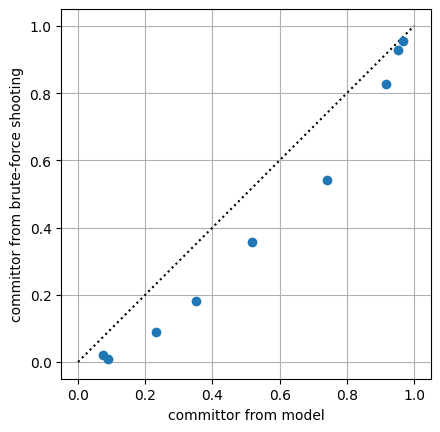

In [47]:
r = np.zeros((len(validation_set), 2), dtype=float)

for shot_paths in params.shot_paths("validation", "sweep"):
    r += shot_paths.shooting_results(sweep_size=len(validation_set))

y_empirical = r[:, 1] / (r[:, 0] + r[:, 1])

plt.plot([0, 1], [0, 1], ":", color="black")
plt.plot(x_model, y_empirical, "o")
plt.xlabel("committor from model")
plt.ylabel("committor from brute-force shooting")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.show()


## 12. Advanced: multistate periodic toy model (optional)

This final section demonstrates how to combine **two AIMMD simulations** that share the same
engine but sample different portions of a **periodic** free-energy landscape.

We define 5 discrete regions along a periodic coordinate:

A — R — B — S — C

and build two coupled AIMMD setups:

- `params1` for transitions between A ↔ B through R (`ARB`, `BRA`),
- `params2` for transitions between B ↔ C through S (`BSC`, `CSB`).

This pattern generalizes to larger state networks in real applications.


In [48]:
# Switch to the periodic toy folder.
PERIODIC_DIR = PosixPath("../../data/1d_periodic").resolve()
PERIODIC_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PERIODIC_DIR)

print("Working directory:", os.getcwd())

# Copy the network module so imports still work from this folder.
os.system("cp ../1d_double_well/network.py .")


Working directory: /home/covino-shared/data/lichtinger/LigandAIMMD/new_aimmd/AIMMD/examples/data/data/data/1d_periodic


0

### 12.1 Periodic toy dynamics and state labeling


In [49]:
def toy_mdrun(ts, G: float = 3.0, dt: float = 1e-4, D: float = 10.0):
    """Overdamped Langevin on a periodic cosine potential."""
    sqrt2Dt = np.sqrt(2 * D * dt)
    x = ts.positions
    for _ in range(100):
        f = -G * np.sin(x)
        x = x - f * dt + sqrt2Dt * np.random.normal()
    ts.positions = x


def states_function(trajectory):
    """Partition x into five regions A/R/B/S/C along [0, 6π)."""
    labels = []
    for ts in trajectory:
        x = ts.positions[0][0]
        if x < np.pi + np.pi / 4:
            labels.append("A")
        elif x < 3 * np.pi - np.pi / 4:
            labels.append("R")
        elif x < 3 * np.pi + np.pi / 4:
            labels.append("B")
        elif x < 5 * np.pi - np.pi / 4:
            labels.append("S")
        else:
            labels.append("C")
    return np.array(labels, dtype="<U1")


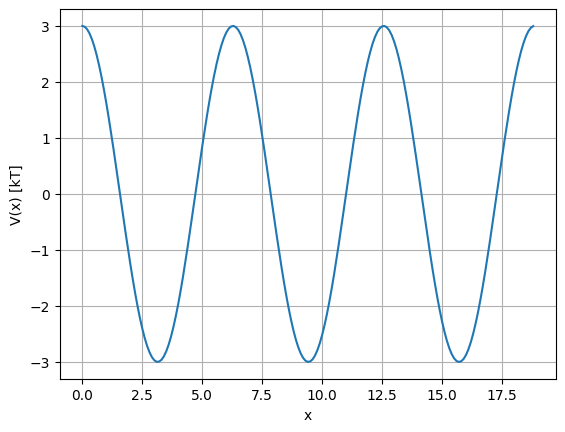

In [50]:
# Initial path: sweep from 0 to 6π.
universe = mda.Universe.empty(1, trajectory=True)
atoms = universe.atoms
ts = universe.trajectory.ts

with mda.coordinates.XTC.XTCWriter("initial_cos.xtc", 1) as writer:
    for x in np.arange(0, np.pi * 6, 0.1):
        ts.positions = x
        writer.write(atoms)

# Visualize the periodic potential.
G = toy_mdrun.__defaults__[0]
pes = lambda x: G * np.cos(x)

xgrid = np.arange(0, np.pi * 6, 0.1)
plt.plot(xgrid, pes(xgrid))
plt.grid(True)
plt.xlabel("x")
plt.ylabel("V(x) [kT]")
plt.show()


### 12.2 Two coupled AIMMD setups

We create two independent `Params` objects. Each one uses a different descriptor transform
that "recenters" the relevant reactive region near zero (useful for learning/stability).


In [51]:
from network import network

params1 = aimmd.Params(
    states_function=states_function,
    engine="toy",
    toy_mdrun=toy_mdrun,
    network=network,
    initial_paths="initial_cos.xtc",
)

# Center reactive region R near 0 (roughly around 2π).
def descriptor_transform(x):
    return x - np.pi * 2 
params1.descriptor_transform = descriptor_transform

params2 = aimmd.Params(
    states_function=states_function,
    engine="toy",
    toy_mdrun=toy_mdrun,
    states="BSC",
    network=network,
    initial_paths="initial_cos.xtc",
)

# Center reactive region S near 0 (roughly around 4π).
def descriptor_transform(x):
    return x - np.pi * 4
params2.descriptor_transform = descriptor_transform

launcher = aimmd.Launcher([params1, params2], "multistate")
launcher


Written full params with descriptions to 'params.py'


Written full params with descriptions to 'params1.py'


Launcher of 2 runs ('multistate', 'multistate')

In [52]:
# Example: you could dedicate one worker to free simulations in B (left as a comment).
launcher.run(n=1, n1=[1, 0], n2=[0, 1], walltime=100, nsteps=30)


Written full params with descriptions to 'params2.py'
+++ created 'multistate'
+++ created 'multistate/initialARB'
+++ saved 'multistate/initialARB/initial_cos.xtc.trr' (from: 'initial_cos.xtc')
+++ saved 'multistate/initialARB/initial_cos.xtc.trr.states.npy'
+++ created multistate/freeA
+++ created multistate/chainR0
Written full params with descriptions to 'params3.py'
+++ created 'multistate/initialBSC'
+++ saved 'multistate/initialBSC/initial_cos.xtc.trr' (from: 'initial_cos.xtc')
+++ saved 'multistate/initialBSC/initial_cos.xtc.trr.states.npy'
+++ created multistate/freeC
+++ created multistate/chainS0
[PID 2896728, TID 140301933188928: "multistate" ARB trainer] starting (Fri Mar  6 16:04:59 2026)[PID 2896727, TID 140381153994560: "multistate" chainR0] starting (Fri Mar  6 16:04:59 2026)[PID 2896731, TID 140185800263488: "multistate" chainS0] starting (Fri Mar  6 16:04:59 2026)


...   args: ('params3.py', 'multistate', np.int64(4), np.int64(4), 1, 'chainS0/worker.log', inf, inf, 

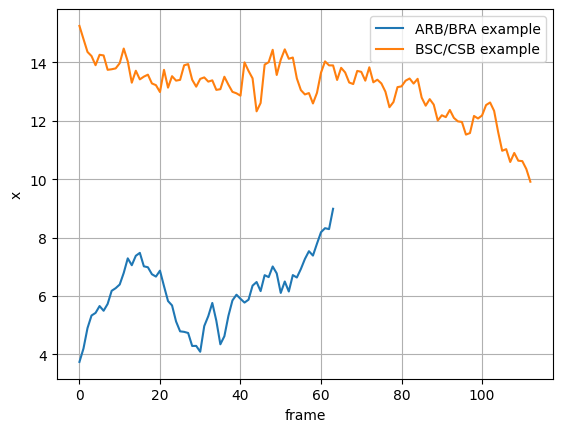

In [53]:
# Loading portions and inspecting them separately.
pathensemble1 = params1.pathensemble("multistate")  # ARB/BRA portion
pathensemble2 = params2.pathensemble("multistate")  # BSC/CSB portion

path1 = pathensemble1.extract("ARB", "BRA")[-1]
path2 = pathensemble2.extract("BSC", "CSB")[-1]

plt.plot(path1.coordinates[:, 0], label="ARB/BRA example")
plt.plot(path2.coordinates[:, 0], label="BSC/CSB example")
plt.legend()
plt.grid(True)
plt.xlabel("frame")
plt.ylabel("x")
plt.show()


### 12.3 Note on shared network instances

In this toy example, `params1` and `params2` share the same Python `network` object.
That is convenient, but it means you must be explicit about which weights you load before
computing values.

For independent training processes in real workflows, prefer separate model instances.


In [54]:
# If you want to overwrite committor values for one portion, reload the matching weights first.
params1.update_network("multistate")  # loads networkARB.h5 (depending on state naming)
pathensemble1.compute(*params1.compute_values_args, overwrite=True)


5150

### 12.4 Inspect the committor model for different transition portions

In the multistate periodic toy, we trained **separate committor models** for different
reactive regions (e.g. **ARB** vs **BSC**). Even if the underlying coordinate `x`
lives in different ranges (different periodic sectors), each model should output a
**consistent committor-like signal** for *its own* transition region.

Important detail in this tutorial setup: `params1` and `params2` share the same Python
`network` instance. Therefore, **you must reload the right weights** before computing
committor values for each portion, otherwise you will silently evaluate with the wrong model.

ARB path:   p min/max = -4.8349385261535645 1.1376829147338867
BSC path:   p min/max = -0.1708049327135086 5.035522937774658


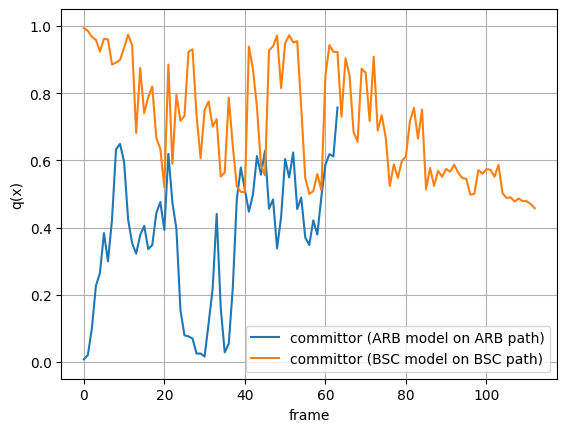

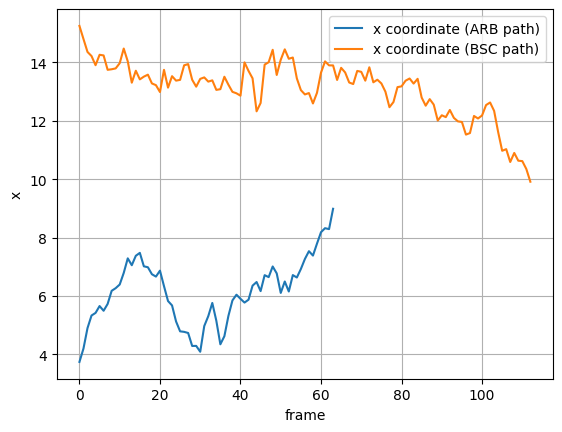

In [56]:
# Pick one representative transition-like path from each portion.
# (Change the selectors if you want different types.)
path1 = pathensemble1.extract("ARB", "BRA")[-1]
path2 = pathensemble2.extract("BSC", "CSB")[-1]

# Because params1/params2 share the same `network` object, always reload weights
# before computing values for each portion.
params1.update_network("multistate")  # typically loads networkARB.h5
path1.compute(*params1.compute_values_args, overwrite=True)

params2.update_network("multistate")  # typically loads networkBSC.h5
path2.compute(*params2.compute_values_args, overwrite=True)

# `path.values` are usually logits (pre-sigmoid). Convert to committor in [0, 1].
q1 = path1.values
q2 = path2.values
p1 = expit(path1.values)
p2 = expit(path2.values)

plt.figure()
plt.plot(p1, label="committor (ARB model on ARB path)")
plt.plot(p2, label="committor (BSC model on BSC path)")
plt.xlabel("frame")
plt.ylabel("q(x)")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()

plt.figure()
plt.plot(path1.coordinates[:, 0], label="x coordinate (ARB path)")
plt.plot(path2.coordinates[:, 0], label="x coordinate (BSC path)")
plt.xlabel("frame")
plt.ylabel("x")
plt.grid(True)
plt.legend()

print("ARB path:   p min/max =", float(q1.min()), float(q1.max()))
print("BSC path:   p min/max =", float(q2.min()), float(q2.max()))

## 13. Takeaways

- The toy engine + state function are the minimal pieces needed to run AIMMD.
- `Params` captures run configuration; `Launcher` executes sampling/training; `PathEnsemble` is the analysis entry point.
- In notebooks, multiprocessing output may be less polished than in terminals; logs in the run folder are the authoritative record.

From here, you can replace the toy engine with a real MD engine backend and replace the state function
with physically meaningful order parameters (distances, contacts, RMSD, etc.).
